https://www.instrumart.com/assets/EX411_manual.pdf?srsltid=AfmBOopFp8z26ugakbMVLsoDMttl2y2J4nW5bqij3gpqdarBoZ7hL8JV

To measure current, we used this multimeter. I do not recall if we used the 50 to 400HZ or 400Hz to 1kHz, or if we used DC or AC (I think we used AC), so we take the worse of the two uncertainties of $\pm$ 3.5% + 10 digits

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
import pandas as pd
from pathlib import Path
from helper import *
from uncertainties import ufloat

In [109]:
# CONFIG
data_dir_path = "/B4 Data/" # Change this between notebooks

TEST_DIR = False

data_dict = {
"-0.01": [1.612, 1.607, 1.607],
"0": [1.644, 1.652, 1.648],
".009": [1.687, 1.681, 1.684],
".039": [1.8, 1.798, 1.803],
".081": [1.943, 1.953, 1.958],
".121": [2.109, 2.1, 2.1],
".16": [2.245, 2.255, 2.258],
".199": [2.411, 2.387, 2.406],
".241": [2.553, 2.578, 2.528],
}


In [110]:
# DIR CONFIG
base_dir_path = str(Path.cwd())
DATA_DIR = base_dir_path + data_dir_path
TEST_CSV = "T0059.CSV"

if TEST_DIR == True:
    print("Test Path: ", DATA_DIR + TEST_CSV)
    df = pd.read_csv(DATA_DIR + TEST_CSV, skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])
    print("Data frame loaded!")

In [111]:
test_csv = TEST_CSV
df_test = pd.read_csv(DATA_DIR + test_csv, skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])
df_test = df_test.apply(pd.to_numeric, errors='coerce') # Foce data types from strings to numbers

# Look at the df
x = df_test["CH1"].to_numpy()
y = df_test["CH2"].to_numpy()
t = df_test["TIME"].to_numpy()

# Verify
print(df_test.dtypes)
print(df_test.head())

TIME               float64
CH1                float64
CH1 Peak Detect    float64
CH2                float64
CH2 Peak Detect    float64
dtype: object
       TIME   CH1  CH1 Peak Detect   CH2  CH2 Peak Detect
0       NaN   NaN              NaN   NaN              NaN
1 -0.528000  0.02             0.06 -0.01             0.03
2 -0.527968  0.02            -0.06  0.01            -0.03
3 -0.527936  0.06             0.06 -0.01             0.03
4 -0.527904 -0.02            -0.06  0.01            -0.05


In [112]:
# Find index where t = 0
idx = find_closest_index(df_test, column_name = 'TIME')
print(f"The index closest to 0 is: {idx}")

The index closest to 0 is: 16501


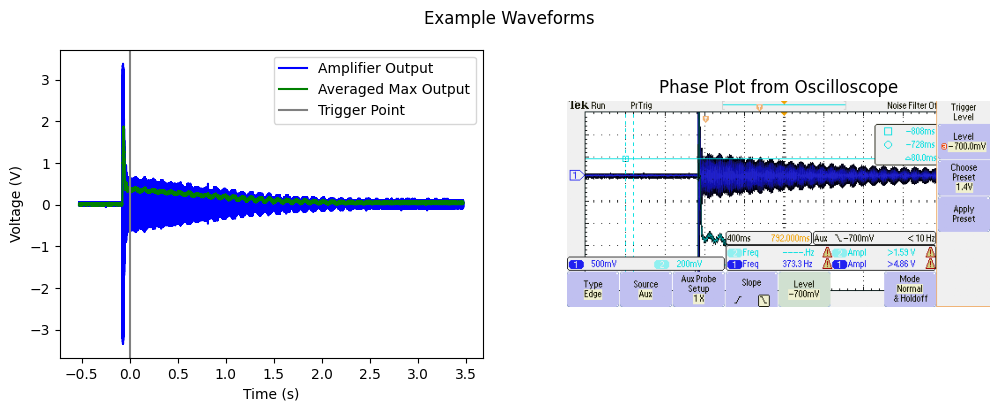

In [113]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Example Waveforms')

# Plot CSV Data on ax1

# Plot CH1 (Signal)
ax1.plot(t, x, label='Amplifier Output', 
                    color='blue')
# Plot CH2 (Averaged Max)
ax1.plot(t, y, label='Averaged Max Output', 
                    color='green')
# Plot Trigger Point
ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")
ax1.legend()

# Plot Image on ax2
img = plt.imread(DATA_DIR + "T0052.png")
ax2.imshow(img)
ax2.set_title("Phase Plot from Oscilloscope")
ax2.axis('off')

plt.show()

In [114]:
start = idx # Set start index at trigger point
end = start + 2000 # Set end index

t_subset = t[start:end]
x_subset = x[start:end]

# For initial guess, do FFT
y_fft = np.fft.rfft(x_subset)
# print(y_fft)
y_fft = np.fft.rfft(x_subset)
freqs = np.fft.rfftfreq(len(t_subset), d=(t_subset[1] - t_subset[0]))
fft_frequency = freqs[np.argmax(np.abs(y_fft))]
print(f"Fast Fourier Transform Frequency: {fft_frequency:.2f} Hz")


# Fit to a sine model
freq = fft_frequency * 2 * np.pi # TODO: Figure out why this needs to be multiplied by 2pi
def sine_fcn(B, x):
    return B[0] * np.sin(freq * x + B[1])
sine_model = odr.Model(sine_fcn)

mydata = odr.RealData(t_subset, x_subset)

sol = odr.ODR(mydata, sine_model, beta0=[0.4, 0])
myoutput = sol.run()
# myoutput.pprint()

Fast Fourier Transform Frequency: 1734.37 Hz


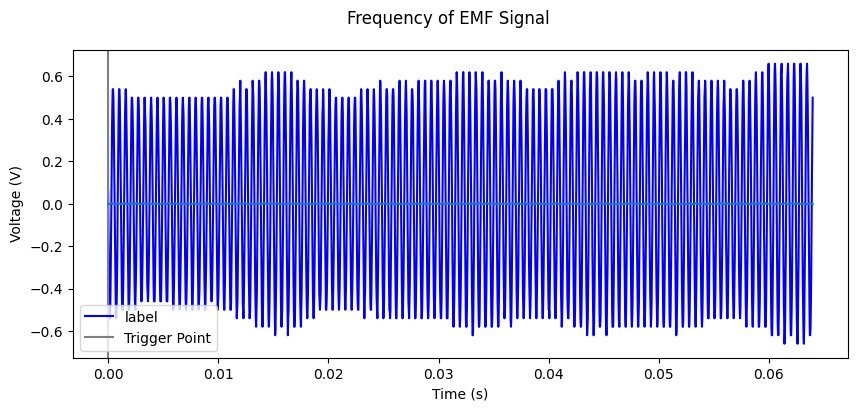

In [115]:
# Plot to see if the FFT frequency is close
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
fig.suptitle('Frequency of EMF Signal')

ax1.plot(t[start:end], x[start:end], label='label', 
                    color='blue')
ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
ax1.legend()
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

# Plot fitted sine wave
fitted_x = sine_fcn(myoutput.beta, t_subset)
ax1.plot(t_subset, fitted_x)

T0052 Had a frequency of 1609.37 Hz. 10053 had a frequency of 1656.25. Som a current of 10mA gave a change in frequency of 26 Hz. This is somewhat close to what we expect, which was 37 Hz.

So a positive current decreases our strength by about 46 Hz?

Looking at 57 and 58 ()

57: (0)     1656.25
58: (.01)   1687.50
59: (.02)   1734.37

# Process Data

In [116]:
current_data = []
freq_means = []
freq_stds = []

for current, freqs in data_dict.items():
    # Look at each of the three CSV's
    current_data.append(eval(current))
    freq_means.append(np.mean(freqs))
    freq_stds.append(np.std(freqs))

current_data = np.array(current_data)
print(current_data)
print(freq_means)
print(freq_stds)

# Get errors on current readings

def ampmeter_uncerts(I):
    return I * 0.015 + 0.0003 # TODO: Recall what mode we used for this!

current_uncerts = ampmeter_uncerts(current_data)
print(current_uncerts)

[-0.01   0.     0.009  0.039  0.081  0.121  0.16   0.199  0.241]
[np.float64(1.608666666666667), np.float64(1.648), np.float64(1.6840000000000002), np.float64(1.8003333333333333), np.float64(1.9513333333333334), np.float64(2.1029999999999998), np.float64(2.252666666666667), np.float64(2.4013333333333335), np.float64(2.5530000000000004)]
[np.float64(0.002357022603955213), np.float64(0.0032659863237109073), np.float64(0.00244948974278318), np.float64(0.002054804667656279), np.float64(0.006236095644623202), np.float64(0.004242640687119236), np.float64(0.005557777333510961), np.float64(0.010338708279513909), np.float64(0.02041241452319308)]
[0.00015  0.0003   0.000435 0.000885 0.001515 0.002115 0.0027   0.003285
 0.003915]


In [117]:
# Fit the data
def linear_fcn(B, x):
    return B[0] * x + B[1]
linear_model = odr.Model(linear_fcn)

mydata = odr.RealData(current_data, freq_means, sx = current_uncerts, sy = freq_stds / np.sqrt(2))

sol = odr.ODR(mydata, linear_model, beta0=[0.4, 0])
myoutput = sol.run()
myoutput.pprint()

Beta: [3.79149621 1.64805022]
Beta Std Error: [0.02271633 0.00082741]
Beta Covariance: [[ 1.05091886e-03 -1.00607548e-05]
 [-1.00607548e-05  1.39421551e-06]]
Residual Variance: 0.4910290587867729
Inverse Condition #: 0.3840799361879912
Reason(s) for Halting:
  Sum of squares convergence


In [118]:
myoutput.beta[1]

np.float64(1.648050215083098)

In [119]:
current_data

array([-0.01 ,  0.   ,  0.009,  0.039,  0.081,  0.121,  0.16 ,  0.199,
        0.241])

In [120]:
linear_fcn(myoutput.beta, np.array(current_data))

array([1.61013525, 1.64805022, 1.68217368, 1.79591857, 1.95516141,
       2.10682126, 2.25468961, 2.40255796, 2.5618008 ])

In [121]:
freq_stds / np.sqrt(3)

array([0.00136083, 0.00188562, 0.00141421, 0.00118634, 0.00360041,
       0.00244949, 0.00320878, 0.00596906, 0.01178511])

<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_43307/3634736393.py:27: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2_{{red}}$: {red_chi_sq:.2f}"


Text(0.67, 0.3, 'Slope: 3.791 ± 0.023\nIntercept: 1.648 ± 0.001\n$\\chi^2_{red}$: 0.49')

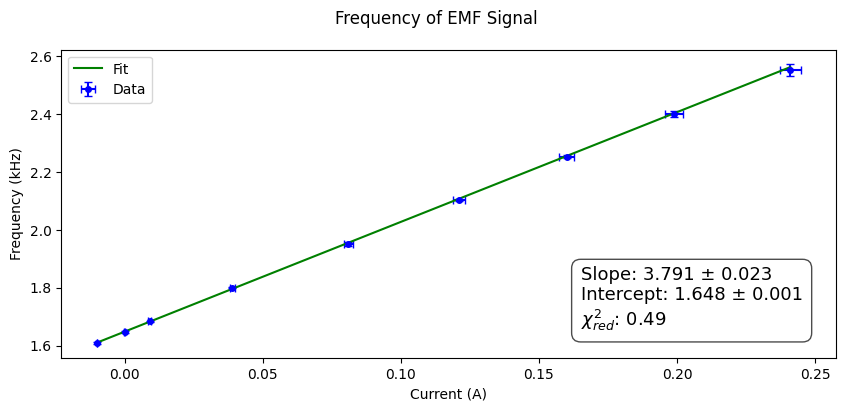

In [122]:
# Plot to see if the FFT frequency is close
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
fig.suptitle('Frequency of EMF Signal')

# ax1.scatter(current_data, freq_means, label='label', color='blue')

ax1.errorbar(current_data, freq_means, xerr = current_uncerts, yerr = freq_stds / np.sqrt(1), fmt='o',
                    color='blue', label='Data', capsize=3, markersize=4)


# Plot best fit
ax1.plot(np.array(current_data), linear_fcn(myoutput.beta, np.array(current_data)), label = 'Fit', color = 'green')
ax1.legend()
ax1.set_ylabel("Frequency (kHz)")
ax1.set_xlabel("Current (A)")

slope = myoutput.beta[0]
slope_error = myoutput.sd_beta[0]
intercept = myoutput.beta[1]
intercept_error = myoutput.sd_beta[1]
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square
stats_text = (
    f"Slope: {slope:.3f} ± {slope_error:.3f}\n"
    f"Intercept: {intercept:.3f} ± {intercept_error:.3f}\n"
    # f"$\chi^2$: {chi_sq:.3f}\n"
    f"$\chi^2_{{red}}$: {red_chi_sq:.2f}"
)
plt.text(0.67, 0.3, stats_text, transform=plt.gca().transAxes, 
         fontsize=13, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

In [123]:
R = 0.307
N = 30
mu_0 = (4 * np.pi) * 10**(-7)
slope * 1000 * R * (5/4)**(3/2) / (N * mu_0) * 2 * np.pi # multiply by 1000 from kHz to Hz


# Don't forget to convert from Hz to rads/second
gamma_proton = slope * 1000 * R * (5/4)**(3/2) / (N * mu_0) * 2 * np.pi # multiply by 1000 from kHz to Hz
gamma_proton_error = slope_error * 1000 * R * (5/4)**(3/2) / (N * mu_0) * 2 * np.pi
# print(f"Gyromagnetic Ratio for proton: {gamma_proton:.4e} rads/second Tesla")

gamma_final = ufloat(gamma_proton, gamma_proton_error)
print(f"Gyromagnetic Ratio for proton: {gamma_final:.4e} rads/second Tesla")

Gyromagnetic Ratio for proton: (2.7112+/-0.0162)e+08 rads/second Tesla
